# **Persiapan & Gathering Data**

In [28]:
from google.colab import drive
drive.mount('/content/drive')

# Memuat data

import pandas as pd
day_df  = pd.read_csv('/content/drive/MyDrive/DICODING/Bike-sharing-dataset/day.csv')
hour_df  = pd.read_csv('/content/drive/MyDrive/DICODING/Bike-sharing-dataset/hour.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Menampilkan 5 data teratas
print(day_df.head())

   instant      dteday  season  yr  mnth  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1        0        6           0   
1        2  2011-01-02       1   0     1        0        0           0   
2        3  2011-01-03       1   0     1        0        1           1   
3        4  2011-01-04       1   0     1        0        2           1   
4        5  2011-01-05       1   0     1        0        3           1   

   weathersit      temp     atemp       hum  windspeed  casual  registered  \
0           2  0.344167  0.363625  0.805833   0.160446     331         654   
1           2  0.363478  0.353739  0.696087   0.248539     131         670   
2           1  0.196364  0.189405  0.437273   0.248309     120        1229   
3           1  0.200000  0.212122  0.590435   0.160296     108        1454   
4           1  0.226957  0.229270  0.436957   0.186900      82        1518   

    cnt  
0   985  
1   801  
2  1349  
3  1562  
4  1600  


# **Assessing Data (Menilai Data)**

In [30]:
# Cek informasi dasar (Tipe data & Missing values)
print("\n--- Info Data Day ---")
print(day_df.info())

# Cek duplikasi
print("\nJumlah duplikasi data day:", day_df.duplicated().sum())

# Cek statistik deskriptif (untuk melihat outlier/keanehan angka)
print("\nStatistik Deskriptif Day:")
print(day_df.describe())


--- Info Data Day ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
None

Jumlah duplikasi data day: 0

Statistik Deskriptif Day:
        

# **Cleaning Data (Pembersihan)**

In [31]:
# 1. Mengubah dteday menjadi datetime
day_df["dteday"] = pd.to_datetime(day_df["dteday"])
hour_df["dteday"] = pd.to_datetime(hour_df["dteday"])

# 2. Mengubah angka menjadi keterangan (agar lebih bermakna)
# Season (1:Spring, 2:Summer, 3:Fall, 4:Winter)
day_df['season'] = day_df['season'].map({
    1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'
})

# Weathersit (1:Clear, 2:Misty/Cloudy, 3:Light Snow/Rain, 4:Heavy Rain)
day_df['weathersit'] = day_df['weathersit'].map({
    1: 'Clear', 2: 'Misty', 3: 'Light Snow/Rain', 4: 'Heavy Rain'
})

# Cek hasil cleaning
print(day_df.head())

   instant     dteday  season  yr  mnth  holiday  weekday  workingday  \
0        1 2011-01-01  Spring   0     1        0        6           0   
1        2 2011-01-02  Spring   0     1        0        0           0   
2        3 2011-01-03  Spring   0     1        0        1           1   
3        4 2011-01-04  Spring   0     1        0        2           1   
4        5 2011-01-05  Spring   0     1        0        3           1   

  weathersit      temp     atemp       hum  windspeed  casual  registered  \
0      Misty  0.344167  0.363625  0.805833   0.160446     331         654   
1      Misty  0.363478  0.353739  0.696087   0.248539     131         670   
2      Clear  0.196364  0.189405  0.437273   0.248309     120        1229   
3      Clear  0.200000  0.212122  0.590435   0.160296     108        1454   
4      Clear  0.226957  0.229270  0.436957   0.186900      82        1518   

    cnt  
0   985  
1   801  
2  1349  
3  1562  
4  1600  


# **Exploratory Data Analysis (EDA)**

In [32]:
# EDA untuk Pertanyaan 1: Performa penyewaan berdasarkan musim di tahun 2012
# Kita filter data hanya untuk tahun 2012 (yr = 1)
day_2012_df = day_df[day_df["yr"] == 1]

season_analysis = day_2012_df.groupby("season").agg({
    "cnt": ["max", "min", "mean", "sum"]
})
print("Analisis Penyewaan berdasarkan Musim (2012):")
print(season_analysis)

# EDA untuk Pertanyaan 2: Hubungan suhu dengan tipe pengguna
# Kita lihat korelasi sederhana antara temp, casual, dan registered
correlation_analysis = day_df[["temp", "casual", "registered", "cnt"]].corr()
print("\nKorelasi antara Suhu dan Tipe Pengguna:")
print(correlation_analysis["temp"])

Analisis Penyewaan berdasarkan Musim (2012):
         cnt                           
         max   min         mean     sum
season                                 
Fall    8714  4073  6824.244681  641479
Spring  7836   441  3531.296703  321348
Summer  8362  1027  6209.489130  571273
Winter  8555    22  5791.865169  515476

Korelasi antara Suhu dan Tipe Pengguna:
temp          1.000000
casual        0.543285
registered    0.540012
cnt           0.627494
Name: temp, dtype: float64


# **Visualization & Explanatory Analysis**

/tmp/ipykernel_835/2354122357.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


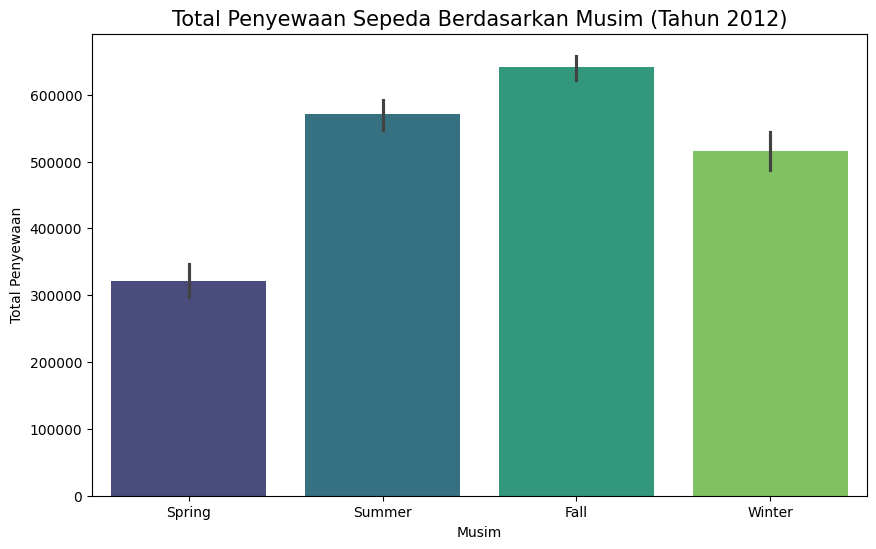

In [33]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x="season",
    y="cnt",
    data=day_2012_df,
    estimator=sum,
    order=['Spring', 'Summer', 'Fall', 'Winter'],
    palette="viridis"
)
plt.title("Total Penyewaan Sepeda Berdasarkan Musim (Tahun 2012)", fontsize=15)
plt.xlabel("Musim")
plt.ylabel("Total Penyewaan")
plt.show()

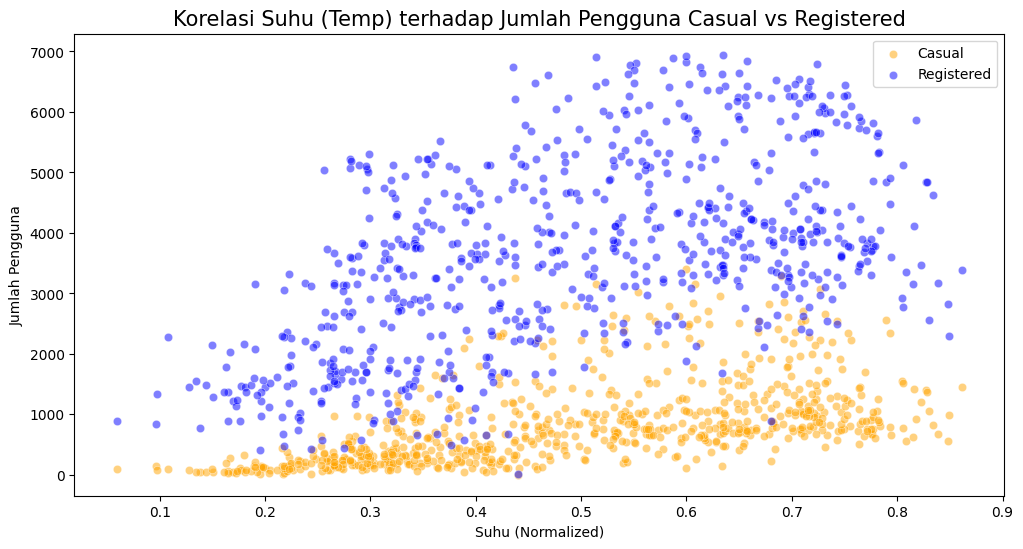

In [34]:
plt.figure(figsize=(12, 6))

# Plot untuk Casual
sns.scatterplot(x="temp", y="casual", data=day_df, alpha=0.5, label="Casual", color="orange")

# Plot untuk Registered
sns.scatterplot(x="temp", y="registered", data=day_df, alpha=0.5, label="Registered", color="blue")

plt.title("Korelasi Suhu (Temp) terhadap Jumlah Pengguna Casual vs Registered", fontsize=15)
plt.xlabel("Suhu (Normalized)")
plt.ylabel("Jumlah Pengguna")
plt.legend()
plt.show()

# **Persiapan Data untuk Dashboard**

In [35]:
# Menyimpan data yang sudah dibersihkan untuk dashboard
day_df.to_csv("main_data.csv", index=False)